In [3]:
import rasterio
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [4]:
def run_kmeans_on_pca(pca_path, n_clusters, output_path=None, visualize=True):
    """
    Applies k-means clustering to a PCA-transformed hyperspectral image.

    Parameters:
    - pca_path (str): Path to the PCA .tif file.
    - n_clusters (int): Number of clusters to compute.
    - output_path (str): Optional path to save the clustered output (.tif). If None, defaults to "<input>_clustered_kmeans.tif".
    - visualize (bool): Whether to show the resulting cluster map.
    
    Returns:
    - cluster_map (2D numpy array): Raster-shaped array of cluster labels.
    """
    with rasterio.open(pca_path) as src:
        pca_array = src.read()  # (bands, rows, cols)
        profile = src.profile

    bands, rows, cols = pca_array.shape
    pca_reshaped = pca_array.reshape(bands, -1).T  # (pixels, bands)

    valid_mask = ~np.isnan(pca_reshaped).any(axis=1)
    pca_clean = pca_reshaped[valid_mask]

    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    kmeans_labels = np.full(pca_reshaped.shape[0], np.nan)
    kmeans_labels[valid_mask] = kmeans.fit_predict(pca_clean)

    cluster_map = kmeans_labels.reshape(rows, cols)

    # Save the result
    profile.update(dtype=rasterio.float32, count=1)
    if output_path is None:
        output_path = pca_path.replace(".tif", "_clustered_kmeans.tif")
    
    with rasterio.open(output_path, "w", **profile) as dst:
        dst.write(cluster_map.astype(rasterio.float32), 1)

    # Optional visualization
    if visualize:
        plt.figure(figsize=(10, 8))
        plt.imshow(cluster_map, cmap="tab20", interpolation="nearest")
        plt.title(f"K-means Clusters (k = {n_clusters})")
        plt.axis("off")
        plt.show()

    return cluster_map

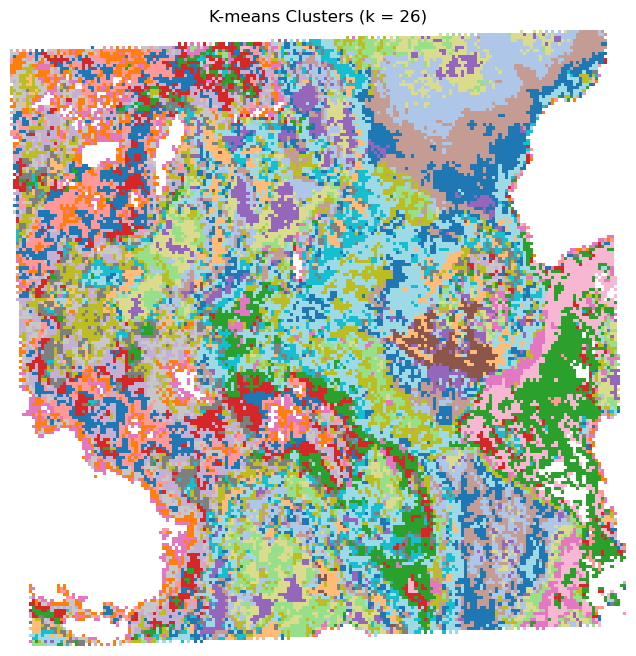

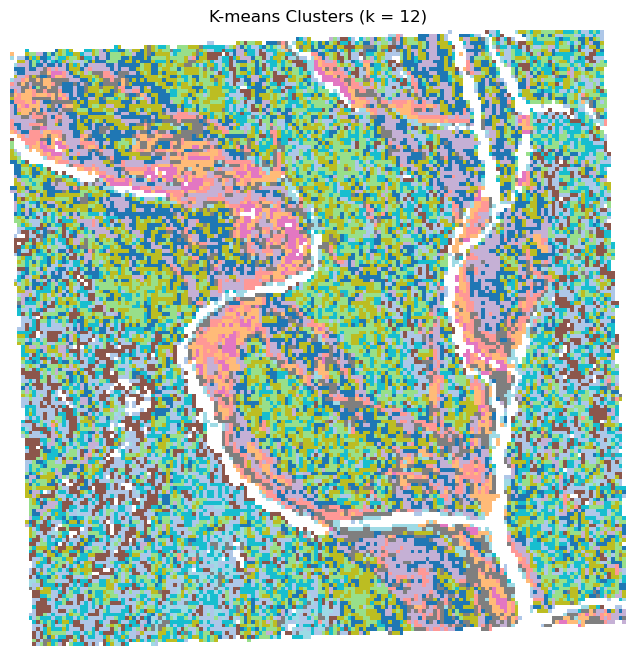

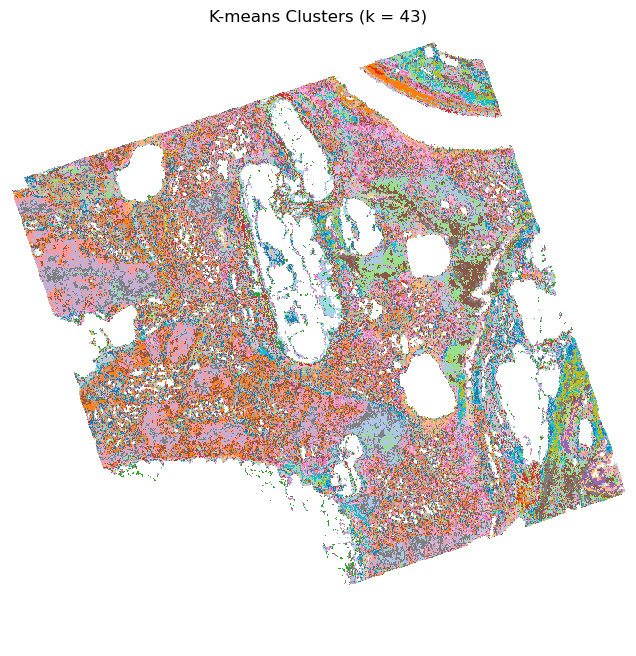

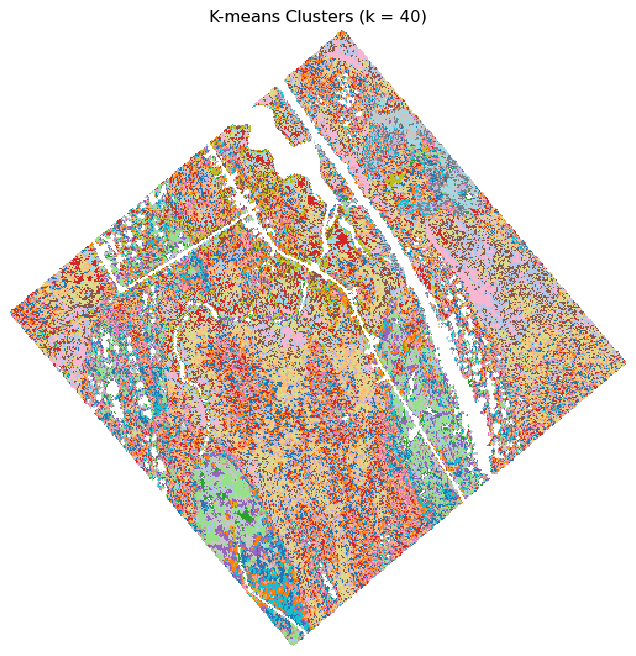

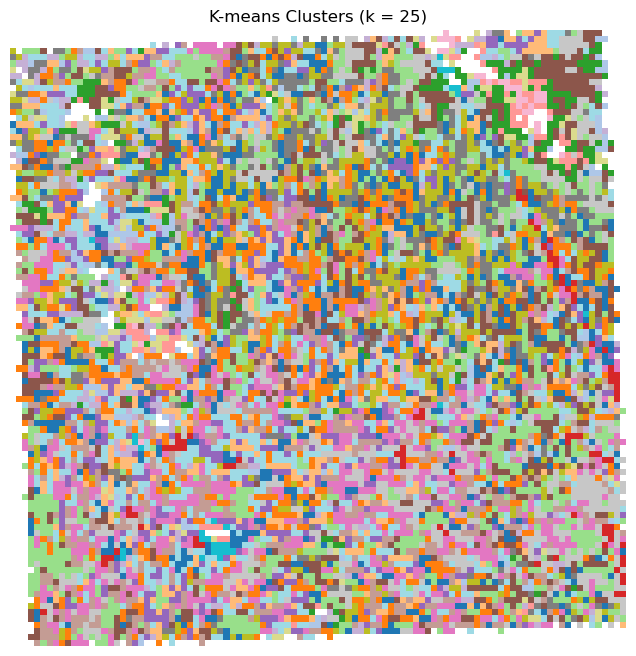

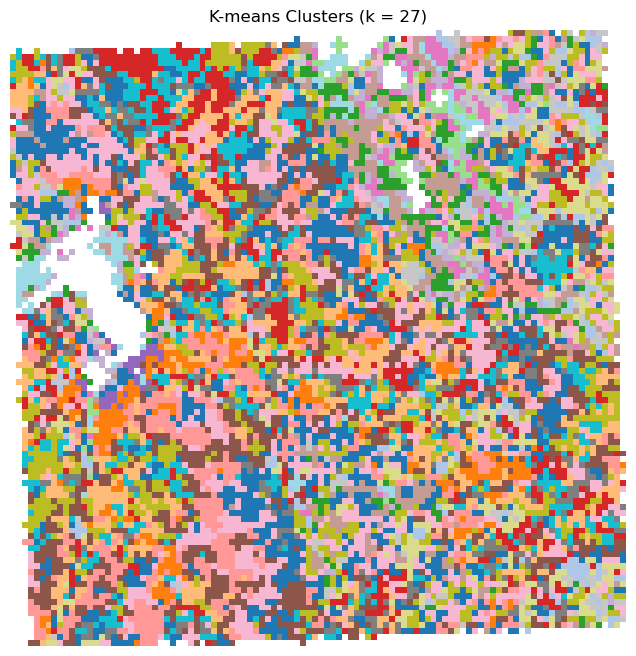

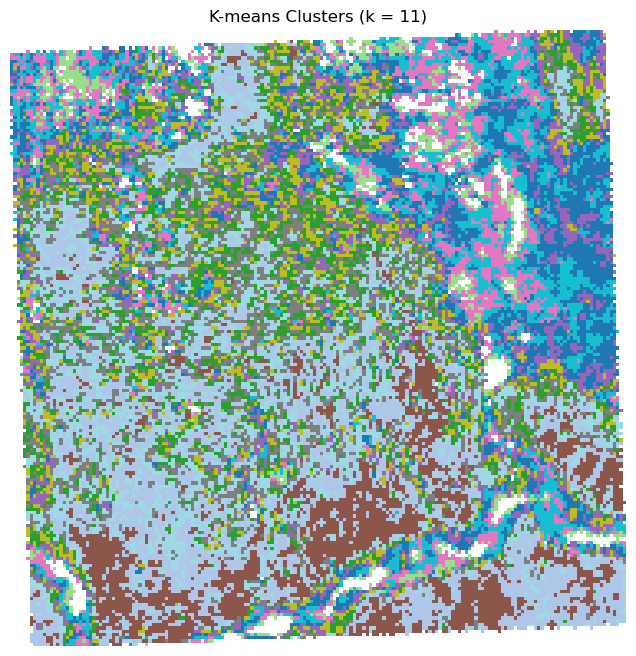

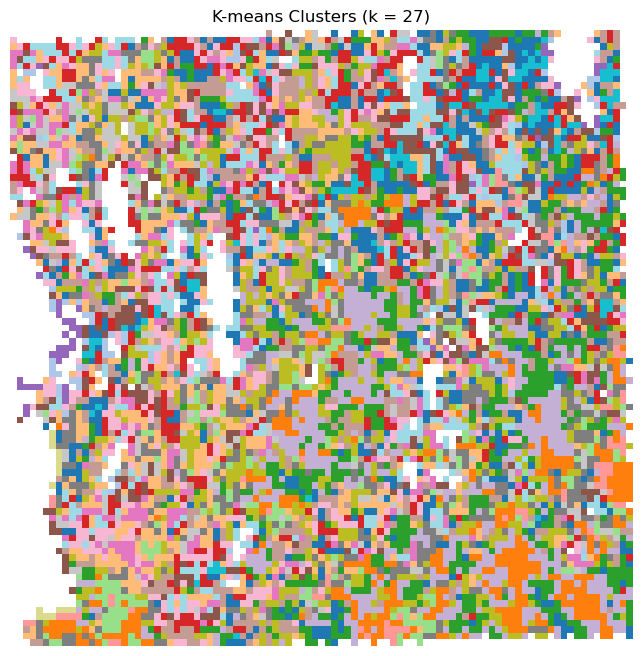

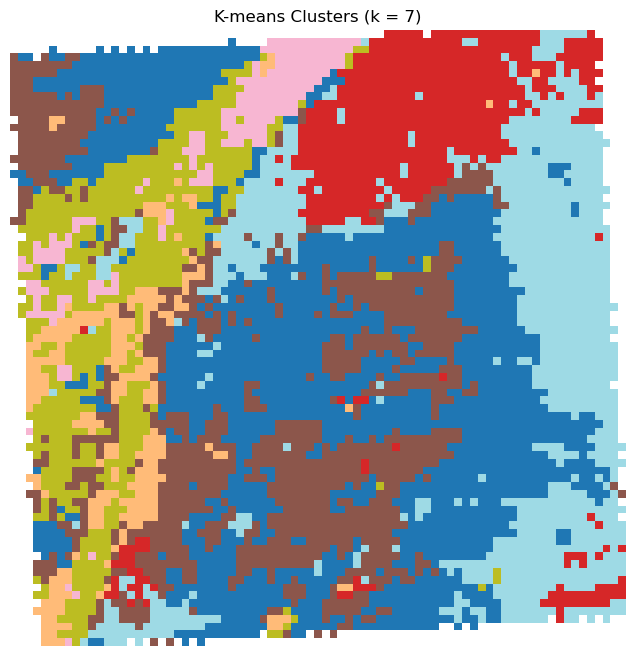

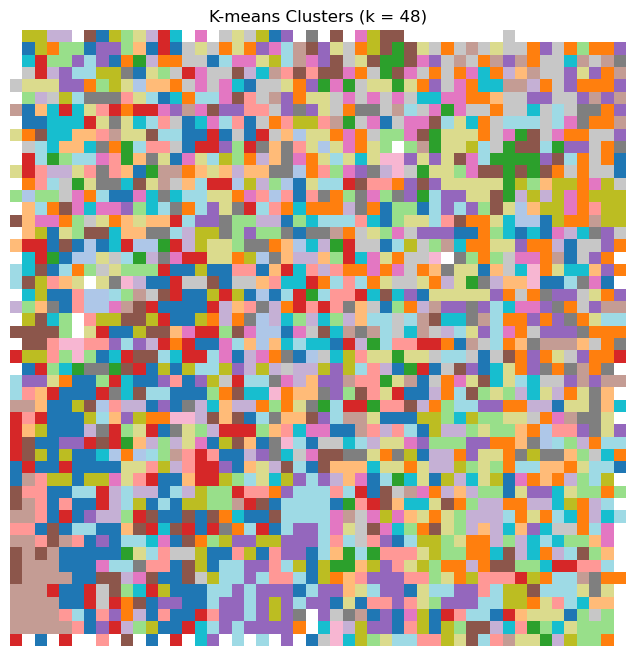

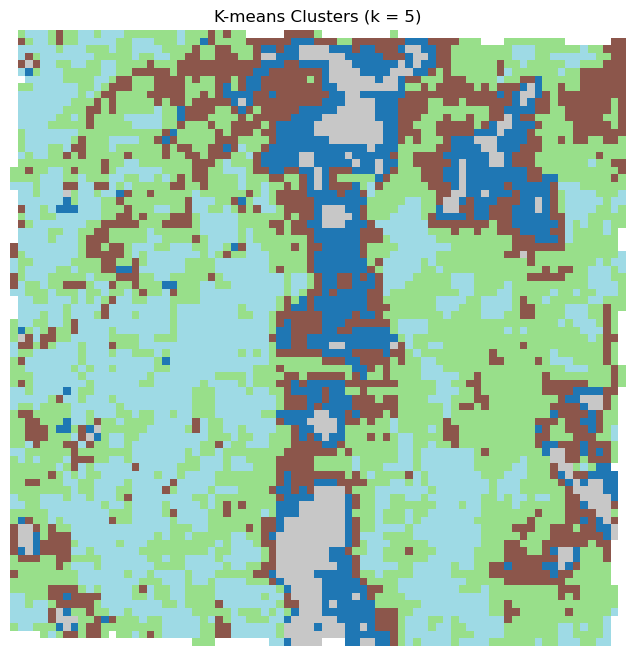

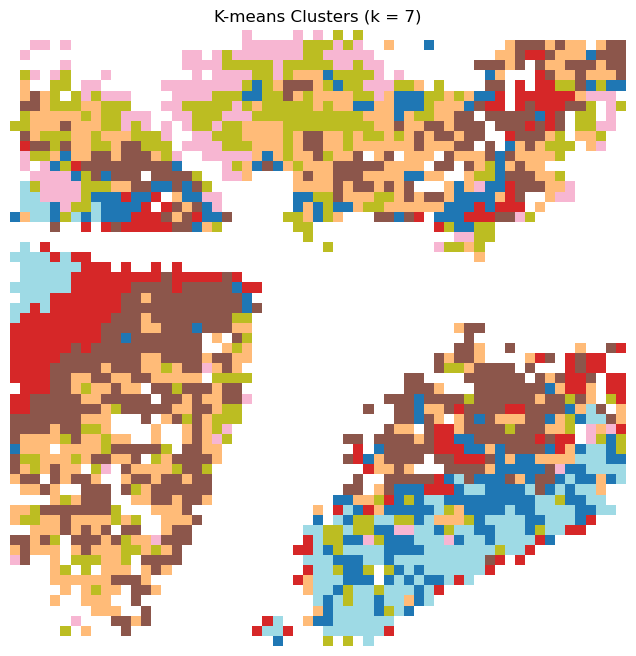

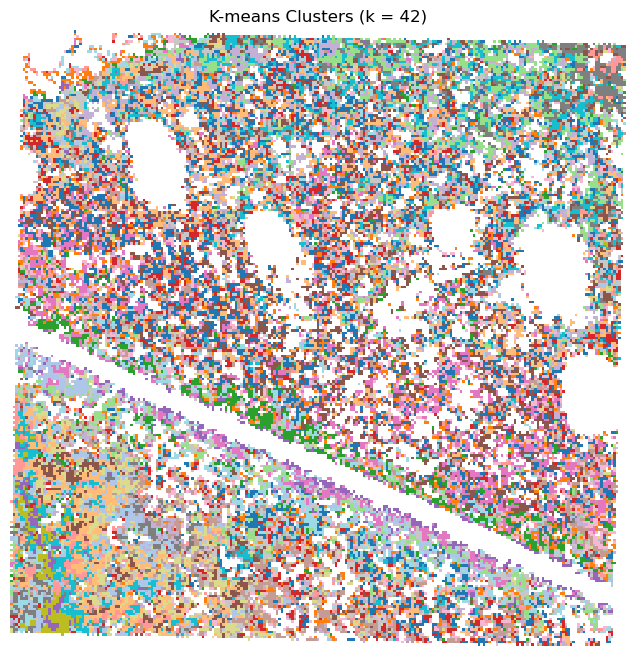

In [8]:
result = run_kmeans_on_pca("SpectralPatang/data/MasterThesis/08_principle_components_selection/AN_TJ_1_pc_selection.tif", n_clusters=26)
result = run_kmeans_on_pca("SpectralPatang/data/MasterThesis/08_principle_components_selection/AN_TJ_2_pc_selection.tif", n_clusters=12)
result = run_kmeans_on_pca("SpectralPatang/data/MasterThesis/08_principle_components_selection/ATQ_VK_1_pc_selection.tif", n_clusters=43)
result = run_kmeans_on_pca("SpectralPatang/data/MasterThesis/08_principle_components_selection/BRW_PW_1_pc_selection.tif", n_clusters=40)
result = run_kmeans_on_pca("SpectralPatang/data/MasterThesis/08_principle_components_selection/BRW_VS_1_pc_selection.tif", n_clusters=25)
result = run_kmeans_on_pca("SpectralPatang/data/MasterThesis/08_principle_components_selection/FLXTWRZONA_SD_1_pc_selection.tif", n_clusters=27)
result = run_kmeans_on_pca("SpectralPatang/data/MasterThesis/08_principle_components_selection/FLXTWRZONA_SD_2_pc_selection.tif", n_clusters=11)
result = run_kmeans_on_pca("SpectralPatang/data/MasterThesis/08_principle_components_selection/FLXTWRZONA_SD_3_pc_selection.tif", n_clusters=27)
result = run_kmeans_on_pca("SpectralPatang/data/MasterThesis/08_principle_components_selection/FLXTWRZONA_SD_4_pc_selection.tif", n_clusters=7)
result = run_kmeans_on_pca("SpectralPatang/data/MasterThesis/08_principle_components_selection/FRST_AK_2_pc_selection.tif", n_clusters=48)
result = run_kmeans_on_pca("SpectralPatang/data/MasterThesis/08_principle_components_selection/FRST_AK_3_pc_selection.tif", n_clusters=5)
result = run_kmeans_on_pca("SpectralPatang/data/MasterThesis/08_principle_components_selection/PRUAIR_DW_1_pc_selection.tif", n_clusters=7)
result = run_kmeans_on_pca("SpectralPatang/data/MasterThesis/08_principle_components_selection/PRUARC_DW_1_pc_selection.tif", n_clusters=42)